# 1) Veri klasörünü indiriniz.

In [ ]:
# import gdown
# import os

# # Dosya ID'si ve hedef dosya adı
# file_id = "1yY3xMT5cSnVK7NK52w3ef-76KLeZ3Vt9"
# output_file = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/Data_Siniflandirma.rar"
# extract_folder = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/Data_Siniflandirma"

# # Google Drive'dan dosyayı indir
# gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1yY3xMT5cSnVK7NK52w3ef-76KLeZ3Vt9
From (redirected): https://drive.google.com/uc?id=1yY3xMT5cSnVK7NK52w3ef-76KLeZ3Vt9&confirm=t&uuid=b1c606c3-b816-4dad-be3d-532aace1b4f3
To: /content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/Data_Siniflandirma.rar
100%|██████████| 608M/608M [00:07<00:00, 84.9MB/s]


'/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/Data_Siniflandirma.rar'

In [ ]:
# !pip install rarfile -q
# import rarfile

# # RAR dosyasını çıkart
# if not os.path.exists(extract_folder):
#     os.makedirs(extract_folder)

# with rarfile.RarFile(output_file) as rf:
#     rf.extractall(extract_folder)

# print(f"Dosya '{output_file}' indirildi ve '{extract_folder}' klasörüne çıkarıldı.")

Dosya '/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/Data_Siniflandirma.rar' indirildi ve '/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/Data_Siniflandirma' klasörüne çıkarıldı.


# 2) Train ve Test klasörlerinin TrainBeyin ve TestBeyin adlı birer kopyasını oluşturunuz.

In [ ]:
# !cp -r "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/Data_Siniflandirma/train" "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/TrainBeyin"
# !cp -r "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/Data_Siniflandirma/test" "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/TestBeyin"

# 3) TrainBeyin ve TestBeyin içerisindeki tüm 0 ve 1 görsellerinde beyin bölgesinin haricindeki kısımlara 0 değerini atayarak dosyaları güncelleyiniz.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Beyin segmentasyonu yapan ve segmentasyon bölgelerindeki boşlukları dolduran fonksiyon
def segment_brain_inside_skull(image_path, skull_threshold=254, brain_threshold=10, max_regions=3, min_region_size=1800):
    # Görüntüyü yükle
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Hata: {image_path} yüklenemedi!")
        return None, None, None, None, None, None

    # 1. Kafatası konturu belirleme
    # Önce görüntüyü yumuşatma
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Kafatasının yüksek yoğunluklu bölgelerini tespit et
    _, skull_thresh = cv2.threshold(blurred, skull_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle kafatasını kalınlaştır
    kernel = np.ones((5, 5), np.uint8)
    skull_dilated = cv2.dilate(skull_thresh, kernel, iterations=2)

    # 2. Kafatası konturunun içini doldur (kafatası boşluğunu elde et)
    # Önce büyük bir kontur elde etmek için morfolojik işlemlerle kapatma
    skull_closed = cv2.morphologyEx(skull_dilated, cv2.MORPH_CLOSE, kernel, iterations=10)

    # Kafatası boşluğunu içerecek şekilde tüm konturları bul
    contours, _ = cv2.findContours(skull_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Kafatası konturu için boş bir maske oluştur
    skull_cavity_mask = np.zeros_like(image)

    # En büyük konturu kafatası olarak varsay ve içini doldur
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        # Convex Hull ile konturu tamamla
        hull = cv2.convexHull(largest_contour)
        cv2.drawContours(skull_cavity_mask, [hull], 0, 255, -1)

    # 3. Beyin bölgesini tespit et
    # Kafatası içindeki bölgelere odaklan (kafatası olmayan bölgeyi al)
    non_skull = cv2.bitwise_not(skull_dilated)

    # Kafatası boşluğu VE kafatası olmayan bölge = sadece kafatası içindeki yumuşak doku
    inner_region = cv2.bitwise_and(skull_cavity_mask, non_skull)

    # Beyin dokusunu diğer yumuşak dokulardan ayırmak için eşikleme
    _, brain_thresh = cv2.threshold(cv2.bitwise_and(blurred, blurred, mask=inner_region),
                                  brain_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle beyin bölgesini temizle
    brain_mask = cv2.morphologyEx(brain_thresh, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=2)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)

    # 4. Büyük bağlantılı beyin bölgelerini seç
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(brain_mask, connectivity=8)

    # Sadece yeterince büyük (min_region_size'dan büyük) bölgeleri filtrele
    filtered_regions = []
    for i in range(1, num_labels):  # 0 indeksi arka plan olduğu için atla
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_region_size:
            filtered_regions.append((i, area))

    # Alan bazında büyükten küçüğe sırala
    filtered_regions.sort(key=lambda x: x[1], reverse=True)

    # En fazla max_regions sayıda bölgeyi seç
    selected_regions = filtered_regions[:max_regions]

    # Seçilen bölgelerin maskelerini hazırla
    final_brain_mask = np.zeros_like(brain_mask)

    # Her bir seçilen bölgeyi ayrı ayrı işle
    for label, _ in selected_regions:
        # Bölgeyi maskele
        current_mask = (labels == label).astype(np.uint8) * 255

        # Bölgedeki boşlukları doldur
        # Konturları bul (dış kontur ve iç boşluklar)
        contours, hierarchy = cv2.findContours(current_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

        # Tüm konturları (dış kontur ve tüm iç boşluklar) doldur
        filled_mask = np.zeros_like(current_mask)
        for i, contour in enumerate(contours):
            # hierarchy[0, i, 3] == -1 ise bu dış kontur demektir
            # Tüm konturları doldurmak istediğimiz için bu kontrolü kullanmıyoruz
            cv2.drawContours(filled_mask, [contour], 0, 255, -1)

        # Doldurulmuş maske ile final maskeyi güncelle
        final_brain_mask = cv2.bitwise_or(final_brain_mask, filled_mask)

    # Boşlukları doldurulmuş maskeyi bir daha işleyelim
    # Alternatif bir yaklaşımla, morfolojik kapatma (closing) işlemi de uygulayalım
    final_brain_mask = cv2.morphologyEx(final_brain_mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)

    # Beyin bölgesini çıkar
    brain_only = cv2.bitwise_and(image, image, mask=final_brain_mask)

    # Görselleştirme için renkli sonuç hazırla
    colored_result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Renkli görselleştirmede her bölgeyi farklı renkle işaretle
    colors = [(0, 255, 0), (0, 255, 255), (255, 0, 255)]  # Yeşil, Sarı, Mor

    # Farklı renklerle segmentasyon görselleştirmesi için tekrar bağlantılı bileşen analizi yap
    # (boşluklar doldurulduktan sonra)
    num_labels_filled, labels_filled = cv2.connectedComponents(final_brain_mask)

    # Her bir seçilen bölge için farklı renk kullan
    for i, (original_label, _) in enumerate(selected_regions):
        if i < len(colors):
            # Doldurulmuş bölgelerdeki yeni etiketi bul
            # En çok örtüşen bölgeyi bul
            max_overlap = 0
            max_overlap_label = 0

            for j in range(1, num_labels_filled):
                # Orijinal maske
                original_mask = (labels == original_label)
                # Yeni maske
                new_mask = (labels_filled == j)
                # Örtüşen pikseller
                overlap = np.sum(np.logical_and(original_mask, new_mask))

                if overlap > max_overlap:
                    max_overlap = overlap
                    max_overlap_label = j

            # En çok örtüşen bölgeyi renklendir
            if max_overlap_label > 0:
                region_mask = (labels_filled == max_overlap_label)
                colored_result[region_mask] = colors[i]

    # Kafatasını kırmızı olarak işaretle
    colored_result[skull_dilated > 0] = [0, 0, 255]

    # Hem seçilen bölgeleri hem de beyin bölgelerinin boyut sıralamasını döndür
    return image, skull_cavity_mask, final_brain_mask, brain_only, colored_result, selected_regions

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# Fonksiyon: Belirtilen klasördeki tüm görüntülere beyin segmentasyonu uygula ve kaydet
def process_brain_images(main_folder, class_folders=[0, 1]):
    total_processed = 0
    total_failed = 0

    for class_folder in class_folders:
        # Klasör yolu oluştur
        folder_path = os.path.join(main_folder, str(class_folder))

        # Klasördeki tüm jpg dosyalarını listele
        image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

        print(f"\nİşleniyor: {folder_path} - Toplam {len(image_files)} dosya")

        # Tüm görüntüleri işle
        for image_file in tqdm(image_files):
            image_path = os.path.join(folder_path, image_file)

            # Beyin segmentasyonu yap
            results = segment_brain_inside_skull(
                image_path,
                skull_threshold=253,
                brain_threshold=30,
                max_regions=3,
                min_region_size=1800
            )

            if results is None or len(results) < 6:
                print(f"  Hata: {image_file} için segmentasyon başarısız!")
                total_failed += 1
                continue

            # Sadece beyin bölgesini al (brain_only)
            brain_only = results[3]

            # Orijinal dosya adıyla kaydet (üzerine yaz)
            cv2.imwrite(image_path, brain_only)
            total_processed += 1

    return total_processed, total_failed

# Ana kod: Tüm dataset'i işle
base_path = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/"

# İşlenecek klasörler
folders_to_process = [
    os.path.join(base_path, "TrainBeyin"),
    os.path.join(base_path, "TestBeyin")
]

# Her bir ana klasör için işleme yap
total_success = 0
total_errors = 0

for folder in folders_to_process:
    print(f"\n{folder} klasörü işleniyor...")
    success, errors = process_brain_images(folder, class_folders=[0, 1])
    total_success += success
    total_errors += errors

print(f"\nİşlem tamamlandı!")
print(f"Toplam başarıyla işlenen görüntü: {total_success}")
print(f"Toplam başarısız işlem: {total_errors}")


/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/TrainBeyin klasörü işleniyor...

İşleniyor: /content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/TrainBeyin/0 - Toplam 4564 dosya


100%|██████████| 4564/4564 [02:44<00:00, 27.74it/s]



İşleniyor: /content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/TrainBeyin/1 - Toplam 2383 dosya


100%|██████████| 2383/2383 [01:25<00:00, 27.73it/s]



/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/TestBeyin klasörü işleniyor...

İşleniyor: /content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/TestBeyin/0 - Toplam 1551 dosya


100%|██████████| 1551/1551 [00:57<00:00, 27.06it/s]



İşleniyor: /content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/TestBeyin/1 - Toplam 950 dosya


100%|██████████| 950/950 [00:34<00:00, 27.37it/s]


İşlem tamamlandı!
Toplam başarıyla işlenen görüntü: 9448
Toplam başarısız işlem: 0


# 4) Ekrana 4 satır ve 5 sütun olacak şekilde 5 adet **"TrainBeyin\0"**, 5 adet **"TrainBeyin\1"**, 5 adet **"TestBeyin\0"**, 5 adet **"TestBeyin\1"** görselini yazdırınız

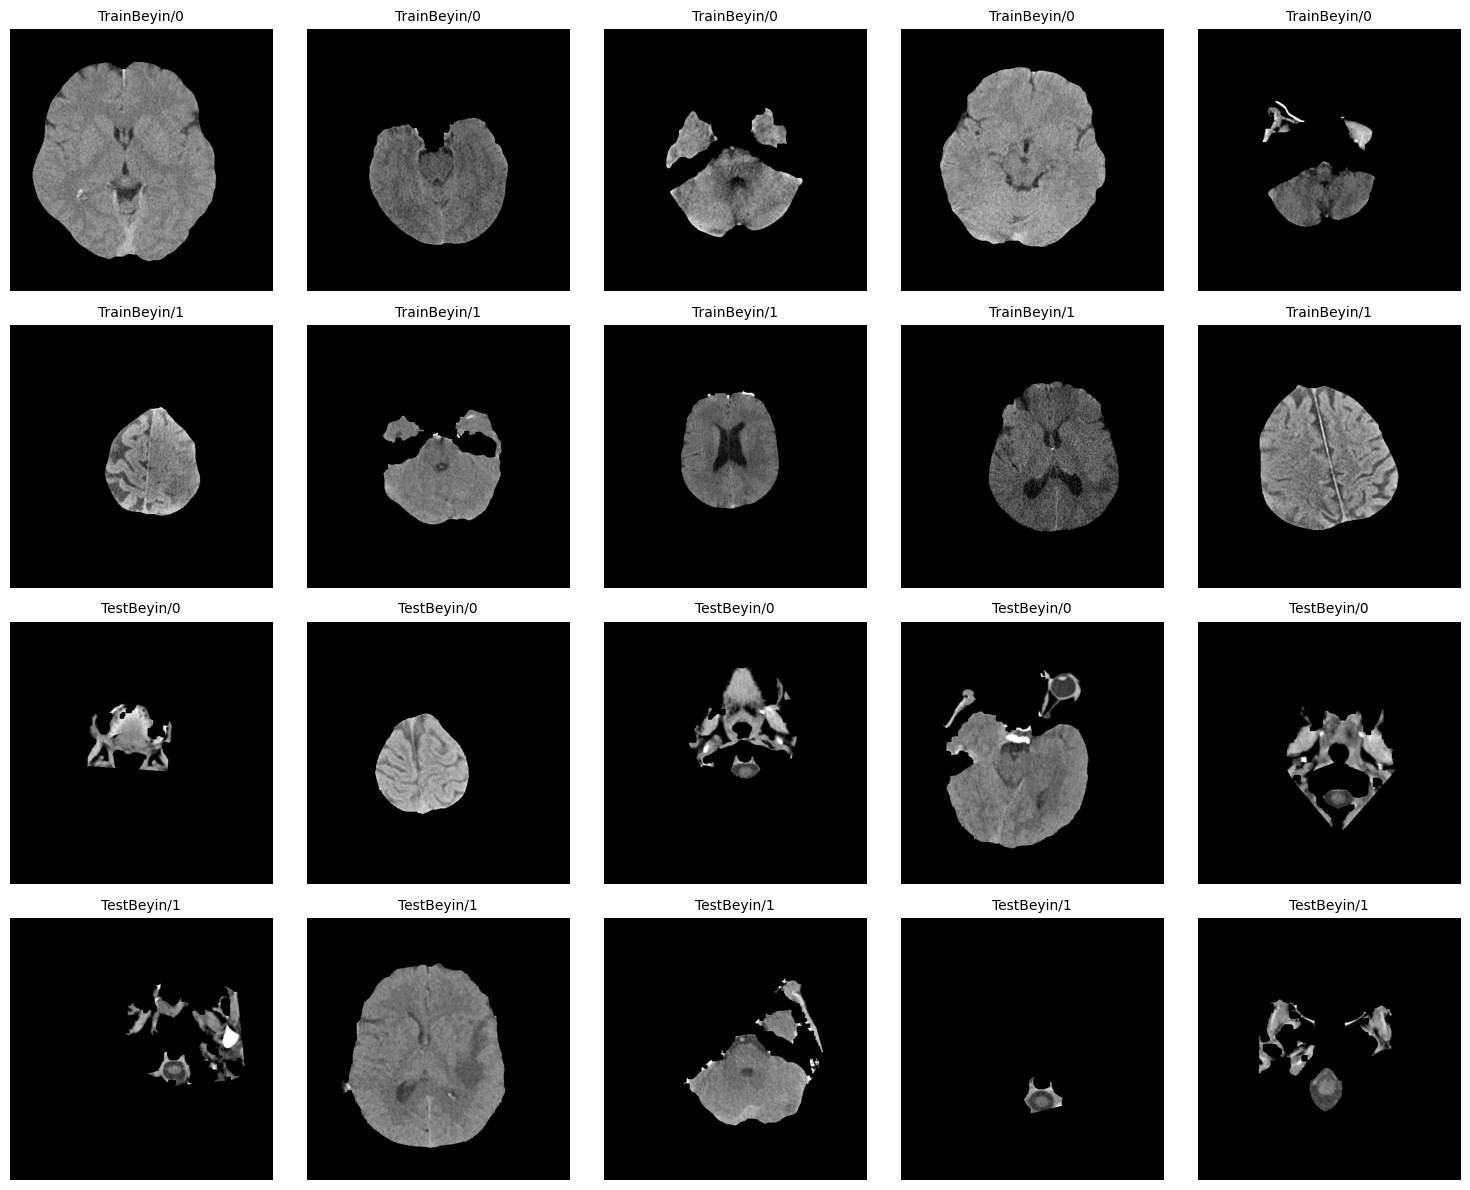

In [ ]:
import matplotlib.pyplot as plt
import os
from matplotlib.image import imread
import random

# Define paths
base_path = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/"
folders = [
    os.path.join(base_path, "TrainBeyin/0"),
    os.path.join(base_path, "TrainBeyin/1"),
    os.path.join(base_path, "TestBeyin/0"),
    os.path.join(base_path, "TestBeyin/1")
]

# Set up the figure with 4 rows, 5 columns
plt.figure(figsize=(15, 12))
folder_names = ["TrainBeyin/0", "TrainBeyin/1", "TestBeyin/0", "TestBeyin/1"]

# For each folder
for folder_idx, folder in enumerate(folders):
    # Get list of jpg image files
    files = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

    # Select 5 random images
    selected_files = random.sample(files, 5)

    # Display each image
    for i, file in enumerate(selected_files):
        img_path = os.path.join(folder, file)
        img = imread(img_path)

        # Calculate position in the grid
        plt.subplot(4, 5, folder_idx * 5 + i + 1)

        # Display image
        plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
        plt.title(f"{folder_names[folder_idx]}", fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()

# 5) TrainBeyin klasöründeki 0 ve 1 görsellerini kullanarak bir model eğitimi gerçekleştiriniz. (%80 eğitim, %20 doğrulama olacak)

## Kütüphaneleri import et

In [1]:
!pip install monai -q

!pip install --upgrade monai -q
!pip install --upgrade numpy -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
monai 1.4.0 requires numpy<2.0,>=1.24, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


In [2]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
import PIL.Image
import cv2
from monai.transforms import (
    Compose,
    Resize,
    ScaleIntensity,
    ToTensor,
    Activations,
    AsDiscrete
)
from monai.networks.nets import DenseNet121
from monai.metrics import ROCAUCMetric
from torch.optim.lr_scheduler import ReduceLROnPlateau
from monai.utils import set_determinism

## Seed belirleyerek deterministik eğitimi etkinleştirin

In [3]:
set_determinism(seed=42)

## Eğitim, doğrulama ve test veri listelerini hazırlayın

In [4]:
# Dosya yolları tanımlanıyor
base_path = "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz/data/"
train_dir = os.path.join(base_path, "TrainBeyin")
test_dir = os.path.join(base_path, "TestBeyin")

# Sınıf isimleri alınıyor (0 ve 1 klasörleri)
class_names = sorted([x for x in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, x))])
num_class = len(class_names)

# Eğitim verilerini toplama
train_image_files = [
    [os.path.join(train_dir, class_names[i], x) for x in os.listdir(os.path.join(train_dir, class_names[i]))]
    for i in range(num_class)
]
train_num_each = [len(train_image_files[i]) for i in range(num_class)]
train_image_files_list = []
train_image_class = []
for i in range(num_class):
    train_image_files_list.extend(train_image_files[i])
    train_image_class.extend([i] * train_num_each[i])

# Test verilerini toplama
test_image_files = [
    [os.path.join(test_dir, class_names[i], x) for x in os.listdir(os.path.join(test_dir, class_names[i]))]
    for i in range(num_class)
]
test_num_each = [len(test_image_files[i]) for i in range(num_class)]
test_image_files_list = []
test_image_class = []
for i in range(num_class):
    test_image_files_list.extend(test_image_files[i])
    test_image_class.extend([i] * test_num_each[i])

# Veri hakkında bilgi
train_total = len(train_image_class)
test_total = len(test_image_class)
if train_total > 0:
    image_width, image_height = PIL.Image.open(train_image_files_list[0]).size
    print(f"Train image count: {train_total}")
    print(f"Image dimensions: {image_width} x {image_height}")
print(f"Test image count: {test_total}")
print(f"Label names: {class_names}")
print(f"Train label counts: {train_num_each}")
print(f"Test label counts: {test_num_each}")

Train image count: 6947
Image dimensions: 512 x 512
Test image count: 2501
Label names: ['0', '1']
Train label counts: [4564, 2383]
Test label counts: [1551, 950]


## Verileri önceden işlemek için MONAI dönüşümlerini, Dataset ve Dataloader'ı tanımlama

In [5]:
# Eğitim verisini Train (%80) ve Validation (%20) olarak bölme
val_frac = 0.2  # %20 doğrulama
length = len(train_image_files_list)
indices = np.arange(length)
np.random.shuffle(indices)

val_split = int(val_frac * length)
val_indices = indices[:val_split]
train_indices = indices[val_split:]

# Eğitim ve doğrulama setlerini oluşturma
train_x = [train_image_files_list[i] for i in train_indices]
train_y = [train_image_class[i] for i in train_indices]
val_x = [train_image_files_list[i] for i in val_indices]
val_y = [train_image_class[i] for i in val_indices]

# Test seti için doğrudan TestBeyin klasöründeki verileri kullan
test_x = test_image_files_list
test_y = test_image_class

print(f"Training count: {len(train_x)}, Validation count: {len(val_x)}, Test count: {len(test_x)}")

Training count: 5558, Validation count: 1389, Test count: 2501


In [6]:
# LoadPNGImage Sınıfı - Eğer kendi tanımınızı kullanmak istiyorsanız
class CustomLoadPNGImage:
    def __call__(self, img_path):
        # PNG formatındaki görüntüyü okuma (tek kanal olarak)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Gri tonlamalı olarak oku
        if image is None:
            raise ValueError(f"Dosya okunamadı: {img_path}")

        # (H, W) formatını (1, H, W) formatına dönüştür
        image = np.expand_dims(image, axis=0)  # (H, W) → (1, H, W)
        return image.astype(np.float32)  # float32 formatında döndür

# Dönüşümler
train_transforms = Compose(
    [
        CustomLoadPNGImage(),
        Resize(spatial_size=(512, 512)),
        ScaleIntensity(),
        ToTensor(),
    ]
)

val_transforms = Compose([
    CustomLoadPNGImage(),
    Resize(spatial_size=(512, 512)),
    ScaleIntensity(),
    ToTensor(),
])

y_pred_trans = Compose([Activations(softmax=True)])
y_trans = Compose([AsDiscrete(to_onehot=num_class)])

In [7]:
# Dataset sınıfı
class BrainStrokeDataset(torch.utils.data.Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]

# DataLoader oluşturma
train_ds = BrainStrokeDataset(train_x, train_y, train_transforms)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8)

val_ds = BrainStrokeDataset(val_x, val_y, val_transforms)
val_loader = DataLoader(val_ds, batch_size=16, num_workers=8)

test_ds = BrainStrokeDataset(test_x, test_y, val_transforms)
test_loader = DataLoader(test_ds, batch_size=16, num_workers=8)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [8]:
# Eğitim veri setindeki sınıf sayılarını yazdırma
train_class_counts = [0] * num_class
for label in train_y:
    train_class_counts[label] += 1

print("Eğitim setindeki sınıf sayıları:")
for i, class_name in enumerate(class_names):
    print(f"Sınıf {class_name}: {train_class_counts[i]} örnek")

# Doğrulama veri setindeki sınıf sayılarını yazdırma
val_class_counts = [0] * num_class
for label in val_y:
    val_class_counts[label] += 1

print("\nDoğrulama setindeki sınıf sayıları:")
for i, class_name in enumerate(class_names):
    print(f"Sınıf {class_name}: {val_class_counts[i]} örnek")

# Test veri setindeki sınıf sayılarını yazdırma
test_class_counts = [0] * num_class
for label in test_y:
    test_class_counts[label] += 1

print("\nTest setindeki sınıf sayıları:")
for i, class_name in enumerate(class_names):
    print(f"Sınıf {class_name}: {test_class_counts[i]} örnek")

# Toplam veri dağılımı
print("\nToplam veri dağılımı:")
for i, class_name in enumerate(class_names):
    total = train_class_counts[i] + val_class_counts[i] + test_class_counts[i]
    print(f"Sınıf {class_name}: {total} örnek")

Eğitim setindeki sınıf sayıları:
Sınıf 0: 3655 örnek
Sınıf 1: 1903 örnek

Doğrulama setindeki sınıf sayıları:
Sınıf 0: 909 örnek
Sınıf 1: 480 örnek

Test setindeki sınıf sayıları:
Sınıf 0: 1551 örnek
Sınıf 1: 950 örnek

Toplam veri dağılımı:
Sınıf 0: 6115 örnek
Sınıf 1: 3333 örnek


## Network ve Optimizer'ı Tanımla

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


In [10]:
from monai.networks.nets import DenseNet121
import torch.nn as nn

model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=num_class).to(device)

In [11]:
# Sınıf ağırlıklarını hesaplama
class_counts = torch.tensor([3655, 1903], dtype=torch.float32)  # Sizin verdiğiniz sayılara göre güncellendi
weights = 1.0 / class_counts
weights = weights / weights.sum()
class_weights = weights.to(device)
print("Sınıf ağırlıkları:", class_weights)

Sınıf ağırlıkları: tensor([0.3424, 0.6576], device='cuda:0')


In [12]:
# Kayıp fonksiyonu ve optimizasyon
loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)

# Initialize ReduceLROnPlateau scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=False)

# Eğitim parametreleri
max_epochs = 16
val_interval = 1
auc_metric = ROCAUCMetric()

## Modeli Eğit

In [13]:
import os
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
from monai.data import decollate_batch

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

for epoch in range(max_epochs):
    print(f"Epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    epoch_len = len(train_ds) // train_loader.batch_size

    # Progress bar for training
    train_progress_bar = tqdm(train_loader, desc="Training", unit="batch", total=epoch_len)

    for batch_data in train_progress_bar:
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # Update progress bar description with current loss
        train_progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    train_progress_bar.close()

    # Calculate and display average loss for this epoch
    avg_epoch_loss = epoch_loss / epoch_len
    epoch_loss_values.append(avg_epoch_loss)
    print(f"Average training loss: {avg_epoch_loss:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")


    if (epoch + 1) % val_interval == 0:
        model.eval()
        print("Validating...")
        with torch.no_grad():
            y_pred = torch.tensor([], dtype=torch.float32, device=device)
            y = torch.tensor([], dtype=torch.long, device=device)

            # Progress bar for validation
            val_progress_bar = tqdm(val_loader, desc="Validation", unit="batch")

            for val_data in val_progress_bar:
                val_images, val_labels = val_data[0].to(device), val_data[1].to(device)
                y_pred = torch.cat([y_pred, model(val_images)], dim=0)
                y = torch.cat([y, val_labels], dim=0)

            val_progress_bar.close()

            # Calculate metrics
            y_onehot = [y_trans(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [y_pred_trans(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)

            # Calculate accuracy
            acc_value = torch.eq(y_pred.argmax(dim=1), y)
            acc_metric = acc_value.sum().item() / len(acc_value)

            # Save model if better
            if result > best_metric:
                best_metric = result
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join("/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz", "model_normal.pth"))
                print("✅ Saved new best metric model")

            # Print validation results
            print(f"AUC: {result:.4f} | Accuracy: {acc_metric:.4f} | Best AUC: {best_metric:.4f} at epoch {best_metric_epoch}")

            # Step the scheduler based on validation metric
            scheduler.step(result)

    print("-" * 40)

print(f"Training completed! Best AUC: {best_metric:.4f} at epoch: {best_metric_epoch}")

Epoch 1/16


Training: 348batch [07:16,  1.25s/batch, loss=0.4123]


Average training loss: 0.5164
Learning Rate: 0.000100
Validating...


Validation: 100%|██████████| 87/87 [01:43<00:00,  1.19s/batch]


✅ Saved new best metric model
AUC: 0.7500 | Accuracy: 0.4701 | Best AUC: 0.7500 at epoch 1
----------------------------------------
Epoch 2/16


...

✅ Saved new best metric model
AUC: 0.9737 | Accuracy: 0.9323 | Best AUC: 0.9737 at epoch 15
----------------------------------------
Epoch 16/16


Training: 348batch [05:33,  1.04batch/s, loss=0.0252]


Average training loss: 0.0393
Learning Rate: 0.000050
Validating...


Validation: 100%|██████████| 87/87 [00:21<00:00,  4.00batch/s]


AUC: 0.9670 | Accuracy: 0.9035 | Best AUC: 0.9737 at epoch 15
----------------------------------------
Training completed! Best AUC: 0.9737 at epoch: 15


 ## Plot the loss and metric

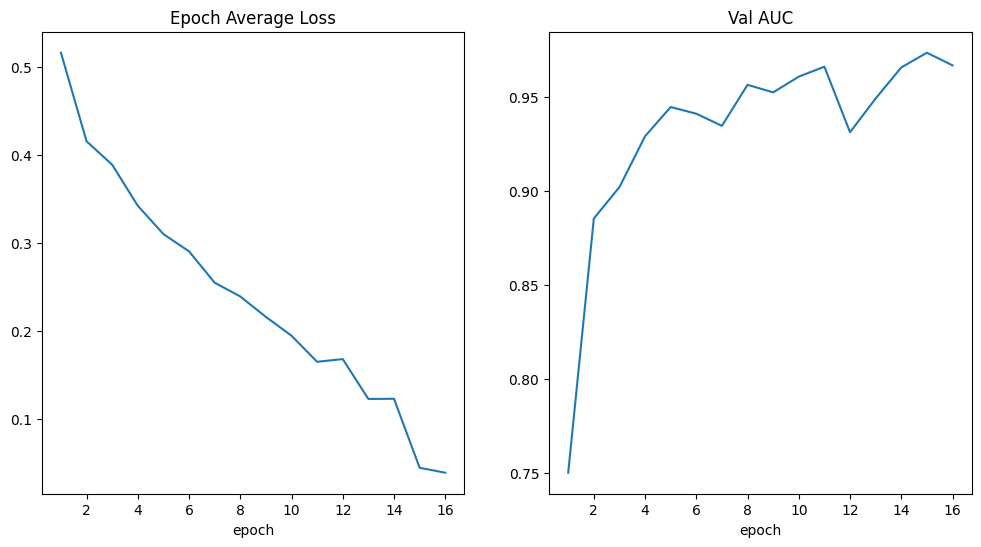

In [14]:
from matplotlib import pyplot as plt

plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val AUC")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

# 6) Eğitilmiş modeli kullanarak 5 adet doğrulama ve 5 adet test görselini sınıflandırınız, title kısmına tahmin sonucunu yazarak ekranda gösteriniz

###**(Test verisi doğru olmadığı için yanlış tahmin ediyor)**

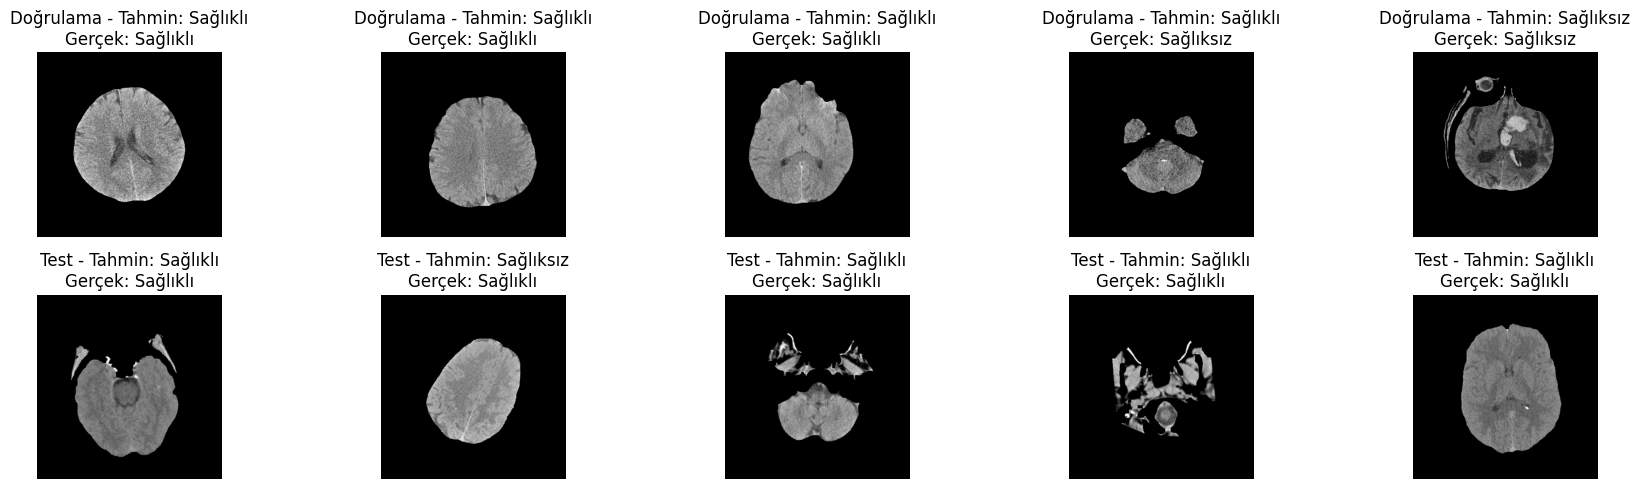

In [15]:
# Eğitilmiş modeli yükle
model.load_state_dict(torch.load(os.path.join(
    "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz", "model_normal.pth")))
model.eval()

# Sınıf isimlerini tanımla
class_names = ["Sağlıklı", "Sağlıksız"]

# Doğrulama setinden 5 görsel seçme ve sınıflandırma
plt.figure(figsize=(18, 5))
with torch.no_grad():
    # Doğrulama setinden 5 görsel
    for i, val_data in enumerate(val_loader):
        if i == 1:  # İlk batch'ten sonra dur
            break
        val_images, val_labels = val_data[0].to(device), val_data[1].to(device)
        val_outputs = model(val_images)
        val_preds = torch.argmax(val_outputs, dim=1)

        # 5 görsel göster
        for j in range(5):
            plt.subplot(2, 5, j+1)
            plt.title(f"Doğrulama - Tahmin: {class_names[val_preds[j]]}\nGerçek: {class_names[val_labels[j]]}")
            plt.imshow(val_images[j, 0].cpu().numpy(), cmap="gray")
            plt.axis("off")

# Test setinden 5 görsel seçme ve sınıflandırma
with torch.no_grad():
    # Test setinden 5 görsel
    for i, test_data in enumerate(test_loader):
        if i == 1:  # İlk batch'ten sonra dur
            break
        test_images, test_labels = test_data[0].to(device), test_data[1].to(device)
        test_outputs = model(test_images)
        test_preds = torch.argmax(test_outputs, dim=1)

        # 5 görsel göster
        for j in range(5):
            plt.subplot(2, 5, j+6)
            plt.title(f"Test - Tahmin: {class_names[test_preds[j]]}\nGerçek: {class_names[test_labels[j]]}")
            plt.imshow(test_images[j, 0].cpu().numpy(), cmap="gray")
            plt.axis("off")

plt.tight_layout()
plt.show()


# 7) Eğitim, doğrulama ve test verileri için confusion matrix'i hesaplayarak ekrana yazdırınız. 
## **Test verisi yanlış olduğu için düşük doğruluğa sahip**

In [16]:
from sklearn.metrics import classification_report

# --- Model Yükleme ---
model.load_state_dict(torch.load(os.path.join(
    "/content/drive/MyDrive/Colab Notebooks/Biyomedikal/5.Quiz", "model_normal.pth")))
model.eval()

class_names = ["Sağlıklı", "Sağlıksız"]

# --- Test Seti Değerlendirme ---
y_true_test = []
y_pred_test = []

with torch.no_grad():
    for test_data in test_loader:
        test_images, test_labels = test_data[0].to(device), test_data[1].to(device)
        pred = model(test_images).argmax(dim=1)
        y_true_test.extend(test_labels.cpu().numpy())
        y_pred_test.extend(pred.cpu().numpy())

print("📊 Test Seti Sonuçları")
print(classification_report(y_true_test, y_pred_test, target_names=class_names, digits=4))


# --- Doğrulama Seti Değerlendirme ---
y_true_val = []
y_pred_val = []

with torch.no_grad():
    for val_data in val_loader:
        val_images, val_labels = val_data[0].to(device), val_data[1].to(device)
        pred = model(val_images).argmax(dim=1)
        y_true_val.extend(val_labels.cpu().numpy())
        y_pred_val.extend(pred.cpu().numpy())

print("\n📊 Doğrulama Seti Sonuçları")
print(classification_report(y_true_val, y_pred_val, target_names=class_names, digits=4))

# --- Eğitim Seti Değerlendirme ---
y_true_train = []
y_pred_train = []

with torch.no_grad():
    for train_data in train_loader:
        train_images, train_labels = train_data[0].to(device), train_data[1].to(device)
        pred = model(train_images).argmax(dim=1)
        y_true_train.extend(train_labels.cpu().numpy())
        y_pred_train.extend(pred.cpu().numpy())

print("\n📊 Doğrulama Seti Sonuçları")
print(classification_report(y_true_train, y_pred_train, target_names=class_names, digits=4))


📊 Test Seti Sonuçları
              precision    recall  f1-score   support

    Sağlıklı     0.6608    0.6518    0.6563      1551
   Sağlıksız     0.4439    0.4537    0.4487       950

    accuracy                         0.5766      2501
   macro avg     0.5523    0.5528    0.5525      2501
weighted avg     0.5784    0.5766    0.5774      2501



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



📊 Doğrulama Seti Sonuçları
              precision    recall  f1-score   support

    Sağlıklı     0.9358    0.9626    0.9490       909
   Sağlıksız     0.9251    0.8750    0.8994       480

    accuracy                         0.9323      1389
   macro avg     0.9305    0.9188    0.9242      1389
weighted avg     0.9321    0.9323    0.9319      1389



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



📊 Doğrulama Seti Sonuçları
              precision    recall  f1-score   support

    Sağlıklı     0.9995    1.0000    0.9997      3655
   Sağlıksız     1.0000    0.9989    0.9995      1903

    accuracy                         0.9996      5558
   macro avg     0.9997    0.9995    0.9996      5558
weighted avg     0.9996    0.9996    0.9996      5558



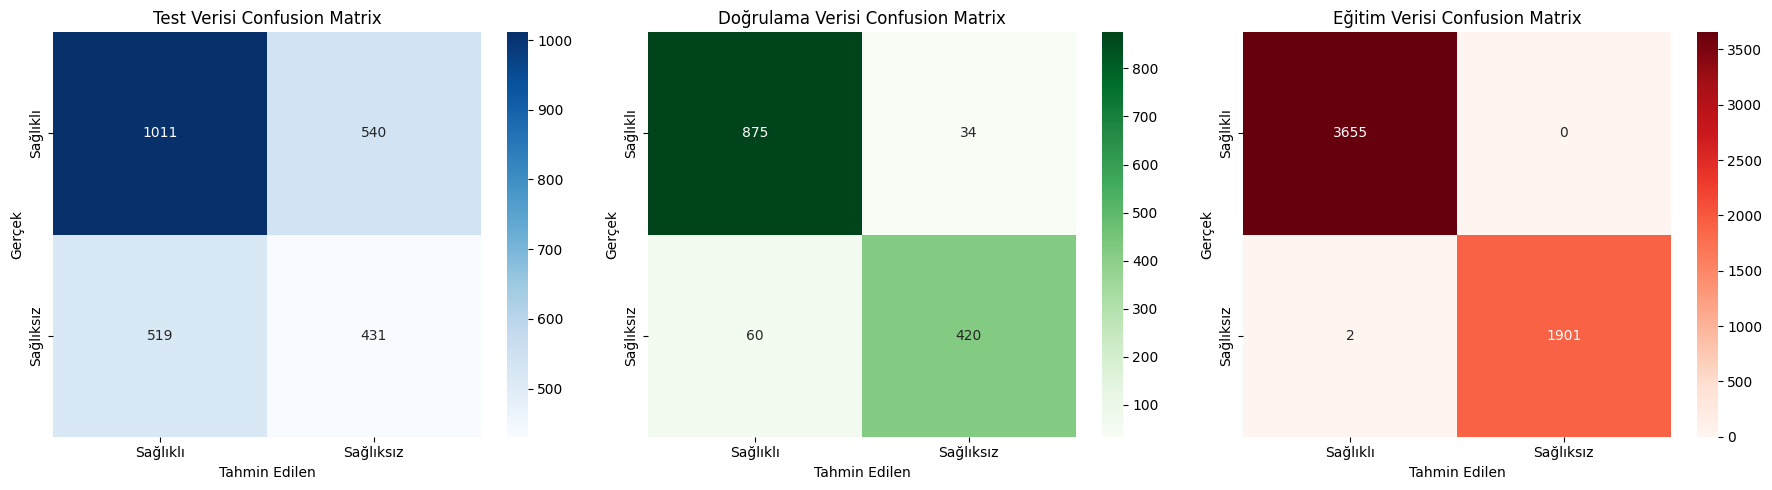

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Confusion Matrix'lerin Hesaplanması ---
cm_test = confusion_matrix(y_true_test, y_pred_test)
cm_val = confusion_matrix(y_true_val, y_pred_val)
cm_train = confusion_matrix(y_true_train, y_pred_train)

# --- Görselleştirme ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Test CM
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Test Verisi Confusion Matrix")
axes[0].set_xlabel("Tahmin Edilen")
axes[0].set_ylabel("Gerçek")

# Validation CM
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Doğrulama Verisi Confusion Matrix")
axes[1].set_xlabel("Tahmin Edilen")
axes[1].set_ylabel("Gerçek")

# Train CM
cm_train = confusion_matrix(y_true_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Reds", xticklabels=class_names, yticklabels=class_names, ax=axes[2])
axes[2].set_title("Eğitim Verisi Confusion Matrix")
axes[2].set_xlabel("Tahmin Edilen")
axes[2].set_ylabel("Gerçek")

plt.tight_layout()
plt.show()


# 8) Test confusion matrix'teki 5 adet False Negative ve False Positive görselini ekranda gösteriniz.

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


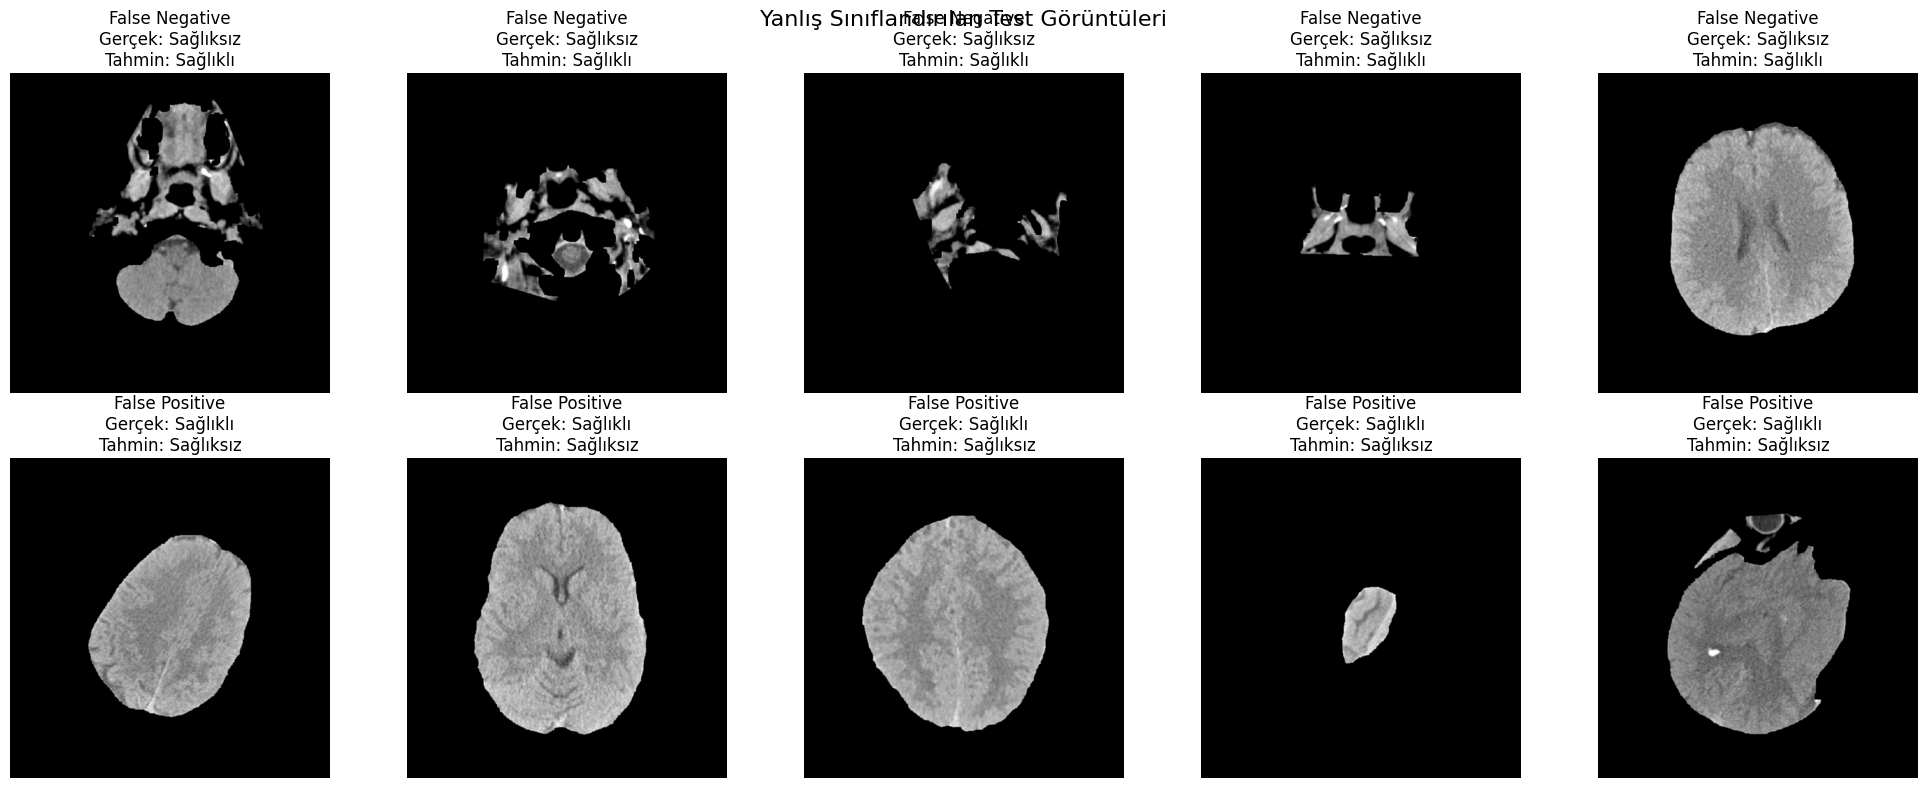

In [18]:
# Find all False Negative and False Positive samples from test set
false_negatives = []
false_positives = []

# We need to get the actual images and their predictions
with torch.no_grad():
    for test_data in test_loader:
        test_images, test_labels = test_data[0].to(device), test_data[1].to(device)
        test_outputs = model(test_images)
        test_preds = torch.argmax(test_outputs, dim=1)

        # Find FN: actual=1 (Sağlıksız), predicted=0 (Sağlıklı)
        fn_indices = (test_labels == 1) & (test_preds == 0)
        for i in range(len(fn_indices)):
            if fn_indices[i]:
                false_negatives.append({
                    'image': test_images[i].cpu().numpy(),
                    'true': test_labels[i].item(),
                    'pred': test_preds[i].item()
                })

        # Find FP: actual=0 (Sağlıklı), predicted=1 (Sağlıksız)
        fp_indices = (test_labels == 0) & (test_preds == 1)
        for i in range(len(fp_indices)):
            if fp_indices[i]:
                false_positives.append({
                    'image': test_images[i].cpu().numpy(),
                    'true': test_labels[i].item(),
                    'pred': test_preds[i].item()
                })

        # Break if we have enough examples
        if len(false_negatives) >= 5 and len(false_positives) >= 5:
            break

# Display images
plt.figure(figsize=(20, 8))

# Display False Negatives (max 5)
fn_count = min(5, len(false_negatives))
for i in range(fn_count):
    plt.subplot(2, 5, i+1)
    plt.imshow(false_negatives[i]['image'][0], cmap='gray')
    plt.title(f"False Negative\nGerçek: {class_names[false_negatives[i]['true']]}\nTahmin: {class_names[false_negatives[i]['pred']]}")
    plt.axis('off')

# Display False Positives (max 5)
fp_count = min(5, len(false_positives))
for i in range(fp_count):
    plt.subplot(2, 5, i+6)
    plt.imshow(false_positives[i]['image'][0], cmap='gray')
    plt.title(f"False Positive\nGerçek: {class_names[false_positives[i]['true']]}\nTahmin: {class_names[false_positives[i]['pred']]}")
    plt.axis('off')

# Add information about count if we don't have 5 of each
if fn_count < 5 or fp_count < 5:
    plt.figtext(0.5, 0.01, f"Not enough examples found: {fn_count} False Negatives, {fp_count} False Positives",
                ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.5, "pad":5})

plt.tight_layout()
plt.suptitle("Yanlış Sınıflandırılan Test Görüntüleri", fontsize=16)
plt.subplots_adjust(top=0.9)
plt.show()